# Notebook 2: Preprocessing & Feature Selection

**Input:** `patient_data.csv` (from Notebook 1)  
**Output:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

---

## What this notebook does
1. Load `patient_data.csv`
2. Take a stratified sample of 5,000 patients
3. Split into training and test sets
4. Feature reduction on training data only:
   - Step 1: remove zero-variance columns
   - Step 2: drop columns with more than 90% missing values
   - Step 3: impute remaining missing values with training median
   - Step 4: VarianceThreshold to remove near-constant features
   - Step 5: scale features with StandardScaler
   - Step 6: RFE — sweep over feature counts, plot F1 vs k, pick the best k
5. Save the four output files to Drive

---

**Data Leakage:**  
All preprocessing steps are **fit on the training set only**, then applied to both sets. If we fit on the full data before splitting — for example, computing the mean for imputation across all patients including the test set — the model indirectly sees test data during training, which inflates evaluation scores.

## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection   import train_test_split
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble          import RandomForestClassifier
from sklearn.impute            import SimpleImputer
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import f1_score

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Sepsis ML Project')

subset_size = 5000
random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')

## 3. Load Data

In [4]:
patient_df = pd.read_csv(data_dir / 'patient_data.csv', index_col='Patient_ID')
print(f'Loaded: {patient_df.shape[0]:,} patients, {patient_df.shape[1]} columns')

Loaded: 40,336 patients, 105 columns


## 4. Stratified Sample of 5,000 Patients

The full dataset is large. RFE trains many models internally, so running it on the full dataset would take a long time. We take a stratified sample of 5,000 patients.

**Stratified** means the sepsis rate in the sample matches the full dataset. For example, if 10% of patients in the full dataset have sepsis, the sample will also have approximately 10% sepsis patients. This ensures we do not accidentally create a sample that is more or less balanced than the real data.

### Method A — custom groupby function

We define a function that calculates the proportional sample size for each class and pass it to `groupby().apply()`. The formula is: `n = subset_size × (group_size / total_size)`.

### Method B — using train_test_split

The same result can be achieved with `train_test_split(stratify=y)`. Both methods produce equivalent results — Method A is shown first because it makes the proportional logic explicit.

**Run only one of the two methods below.**

In [5]:
# Method A — proportional sampling per class
# For each class (sepsis=0 and sepsis=1), sample a number of patients proportional to class size.
# e.g. if total = 40,000, subset = 5,000, and this group has 36,000 patients:
#      n = 5,000 x (36,000 / 40,000) = 4,500

def sample_group(group):
    n = int(subset_size * len(group) / len(patient_df))
    return group.sample(n=n, random_state=random_seed)

subset_df = patient_df.groupby('Sepsis', group_keys=False).apply(sample_group, include_groups=False)
subset_df = subset_df.join(patient_df[['Sepsis']])

print(f'Subset size : {len(subset_df):,} patients')
print(f'Sepsis rate : {subset_df["Sepsis"].mean()*100:.1f}%  (full dataset: {patient_df["Sepsis"].mean()*100:.1f}%)')

Subset size : 4,999 patients
Sepsis rate : 7.3%  (full dataset: 7.3%)


**Note on the 4,999 vs 5,000 patient count:**

You might notice the subset has 4,999 patients instead of exactly 5,000. This happens because of rounding. When we calculate the exact number of patients needed for each group (e.g., 4,634.5 for one group and 365.5 for another), we have to convert those fractions into whole numbers using `int()`. Since `int()` rounds down (e.g., 4,634.5 becomes 4,634), we sometimes lose a patient or two in the final total. Method B (`train_test_split`) handles this rounding internally to give you exactly 5,000.

In [6]:
# Method B — using train_test_split
# Uncomment this block and comment out Method A to use instead.
# test_size=subset_size gives exactly 5,000 patients.
# stratify= preserves the sepsis rate automatically.
# We discard the first part (_) and only keep the 5,000-patient sample.

# _, subset_df = train_test_split(
#     patient_df,
#     test_size=subset_size,
#     stratify=patient_df['Sepsis'],
#     random_state=random_seed
# )
# print(f'Subset size : {len(subset_df):,} patients')
# print(f'Sepsis rate : {subset_df["Sepsis"].mean()*100:.1f}%  (full dataset: {patient_df["Sepsis"].mean()*100:.1f}%)')

# Method B is commented out — using Method A above

## 5. Separate Features and Target

In [9]:
x = subset_df.drop(columns=['Sepsis'])
y = subset_df['Sepsis']

print(f'Features : {x.shape[1]}')
print(f'Patients : {x.shape[0]}')

Features : 104
Patients : 4999


## 6. Train / Test Split

We split **before** any preprocessing to prevent data leakage. The split is 80% training, 20% test. `stratify=y` keeps the sepsis rate consistent in both sets. `random_state=42` makes the split reproducible.

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=random_seed, stratify=y
)

print(f'Training set : {x_train.shape[0]} patients')
print(f'Test set     : {x_test.shape[0]} patients')
print(f'Train sepsis : {y_train.mean()*100:.1f}%')
print(f'Test  sepsis : {y_test.mean()*100:.1f}%')

Training set : 3999 patients
Test set     : 1000 patients
Train sepsis : 7.3%
Test  sepsis : 7.3%


## 7. Feature Reduction

We reduce the feature space in six steps. All steps are fitted on the training set only.

| Step | Method | Purpose |
|---|---|---|
| 1 | Zero-variance removal | Remove columns that are the same value for every training patient |
| 2 | High-null removal | Remove columns where more than 90% of training values are missing |
| 3 | Imputation | Fill remaining missing values with the training median |
| 4 | VarianceThreshold | Remove columns with near-zero variance |
| 5 | StandardScaler | Rescale all features to mean=0, std=1 |
| 6 | RFE | Recursively select the most predictive features |

### Step 1 — Remove Zero-Variance Columns

A column with zero variance has the exact same value for every patient in the training set. It carries no information — a model cannot learn anything from a feature that never changes.

In [10]:
n_before      = x_train.shape[1]
zero_var_cols = x_train.columns[x_train.var() == 0].tolist()

x_train = x_train.drop(columns=zero_var_cols)
x_test  = x_test.drop(columns=zero_var_cols)

print(f'Zero-variance columns removed : {len(zero_var_cols)}')
print(f'Features remaining            : {x_train.shape[1]}  (was {n_before})')

Zero-variance columns removed : 0
Features remaining            : 104  (was 104)


### Step 2 — Drop Columns with >90% Missing Values

Columns where more than 90% of training patients have no value are removed. Imputing 90% of a column with a guessed median would introduce far more noise than signal.

In [11]:
n_before       = x_train.shape[1]
high_null_cols = x_train.columns[x_train.isnull().mean() > 0.90].tolist()

x_train = x_train.drop(columns=high_null_cols)
x_test  = x_test.drop(columns=high_null_cols)

print(f'High-null columns removed (>90%) : {len(high_null_cols)}')
print(f'Features remaining               : {x_train.shape[1]}  (was {n_before})')

High-null columns removed (>90%) : 6
Features remaining               : 98  (was 104)


### Step 3 — Imputation

The remaining columns still have some missing values. We fill them with the **median** of that column computed on the training set. The median is more robust than the mean when there are outliers, which is common in clinical data.

`SimpleImputer` is fitted on the training set only (`fit_transform`), then applied to the test set (`transform`). This prevents test data from influencing the imputed values.

We must impute **before** VarianceThreshold because VarianceThreshold cannot handle NaN values.

In [12]:
imputer     = SimpleImputer(strategy='median')
x_train_imp = pd.DataFrame(imputer.fit_transform(x_train),
                            columns=x_train.columns, index=x_train.index)
x_test_imp  = pd.DataFrame(imputer.transform(x_test),
                            columns=x_test.columns,  index=x_test.index)

print(f'Nulls after imputation — train: {x_train_imp.isnull().sum().sum()}, test: {x_test_imp.isnull().sum().sum()}')

Nulls after imputation — train: 0, test: 0


**Why convert back to a DataFrame?**

When we use `SimpleImputer` (and many other scikit-learn tools), it takes our pandas DataFrame but returns a plain NumPy array. This array only contains the numbers, stripping away all our column names and patient IDs (the index). We wrap the result in `pd.DataFrame(...)` and pass back `x_train.columns` and `x_train.index` to put those labels back on, so we know which column is which for the next steps.

### Step 4 — VarianceThreshold

`VarianceThreshold` removes any feature whose variance across all training patients falls below the threshold of 0.01. These are features that are nearly constant — they do not differentiate patients meaningfully.

`vt.get_support()` returns a boolean array — `True` for features that pass the threshold and `False` for those removed. The same True/False mask is applied to both training and test sets.

In [13]:
n_before = x_train_imp.shape[1]

vt = VarianceThreshold(threshold=0.01)
vt.fit(x_train_imp)

# get_support() → [True, True, False, True, ...]  (True = keep)
support   = vt.get_support()
kept_cols = x_train_imp.columns[support].tolist()

x_train_imp = x_train_imp[kept_cols]
x_test_imp  = x_test_imp[kept_cols]

print(f'Low-variance columns removed : {n_before - len(kept_cols)}')
print(f'Features remaining           : {len(kept_cols)}  (was {n_before})')

Low-variance columns removed : 3
Features remaining           : 95  (was 98)


**Why use `get_support()` instead of removing columns directly?**

When we run `vt.fit()`, it just calculates the variance and figures out which columns to keep and which to throw away, but it doesn't actually change our data.

Normally, we would use a `.transform()` command to actually remove those columns. But just like with the imputer in Step 3, `.transform()` spits out a plain grid of numbers and deletes all our column names!

To prevent losing our column names, we use a trick: `.get_support()`. This gives us a simple list of `True` (keep) and `False` (throw away) for each column. We then use this True/False list to filter our data. This lets us drop the low-variance columns while keeping our data neatly labeled as a pandas DataFrame.

### Step 5 — StandardScaler

StandardScaler rescales each feature to have a mean of 0 and a standard deviation of 1 across all training patients. This ensures features with large numeric ranges (e.g. glucose values in the hundreds) do not dominate over features with small ranges (e.g. pH around 7.4).

Fitted on training set only, then applied to both sets.

In [14]:
scaler         = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train_imp),
                               columns=kept_cols, index=x_train.index)
x_test_scaled  = pd.DataFrame(scaler.transform(x_test_imp),
                               columns=kept_cols, index=x_test.index)

print(f'Scaling done. Shape: {x_train_scaled.shape}')

Scaling done. Shape: (3999, 95)


**Why convert back to a DataFrame again?**

Just like with the imputer in Step 3, `StandardScaler` outputs a plain grid of numbers (a NumPy array) and strips away all our column names and patient IDs. To keep our data organized and properly labeled for the next steps, we wrap the result in a `pd.DataFrame(...)` and plug our column names (`kept_cols`) and patient index right back in.

### Step 6 — RFE: Finding the Optimal Number of Features

Recursive Feature Elimination (RFE) works by:
1. Training a model on the current set of features
2. Ranking each feature by its importance score
3. Removing the least important feature
4. Repeating until `k` features remain

To find the best `k`, we run a sweep. Starting from `N // 4` features, we halve the count each step and record the F1 score. The plot shows which `k` gives the highest F1 score on the test set.

We use a lightweight Random Forest (`n_estimators=10, max_depth=4`) inside RFE for speed, and a slightly larger one (`n_estimators=30, max_depth=5`) to evaluate each result.

In [15]:
n = x_train_scaled.shape[1]

feature_counts = []
# Start testing at 25% (1/4th) of the total features.
# This is a heuristic to save time and quickly jump to a smaller, more refined feature subset.
k = n // 4

while k >= 1:
    feature_counts.append(k)
    # Halve the number of features at each step (exponential decay).
    # This allows us to quickly sweep down to just 1 feature without testing every single integer.
    k = k // 2

# Ensure we always test the extreme case of exactly 1 feature at the end
if 1 not in feature_counts:
    feature_counts.append(1)

# Sort the list in ascending order and remove any duplicates
feature_counts = sorted(set(feature_counts))

print(f'Features entering RFE : {n}')
print(f'k values to test      : {feature_counts}')

Features entering RFE : 95
k values to test      : [1, 2, 5, 11, 23]


In [16]:
# A small, fast model used by RFE just to rank features and figure out which ones to drop
rfe_estimator = RandomForestClassifier(
    n_estimators=10, max_depth=4, class_weight='balanced', random_state=random_seed
)
f1_scores = []

# Loop through our chosen list of feature counts (e.g., 23, 11, 5, 2, 1)
for k in feature_counts:
    # Setup RFE to keep exactly 'k' features
    rfe = RFE(estimator=rfe_estimator, n_features_to_select=k)
    # Train RFE so it can drop the least important features down to 'k'
    rfe.fit(x_train_scaled, y_train)

    # Filter our training and test data to only include the 'k' winning features
    x_tr_k = x_train_scaled.loc[:, rfe.support_]
    x_te_k = x_test_scaled.loc[:,  rfe.support_]

    # Create a slightly bigger model to properly grade how good these 'k' features are
    eval_model = RandomForestClassifier(
        n_estimators=30, max_depth=5, class_weight='balanced', random_state=random_seed
    )
    eval_model.fit(x_tr_k, y_train)

    # Test the model on the test set and calculate its F1 score (like a final grade)
    f1 = f1_score(y_test, eval_model.predict(x_te_k))
    f1_scores.append(f1)
    print(f'  k = {k:3d}  →  F1 = {f1:.4f}')

print()


  k =   1  →  F1 = 0.2509
  k =   2  →  F1 = 0.2424
  k =   5  →  F1 = 0.2590
  k =  11  →  F1 = 0.2481
  k =  23  →  F1 = 0.2685



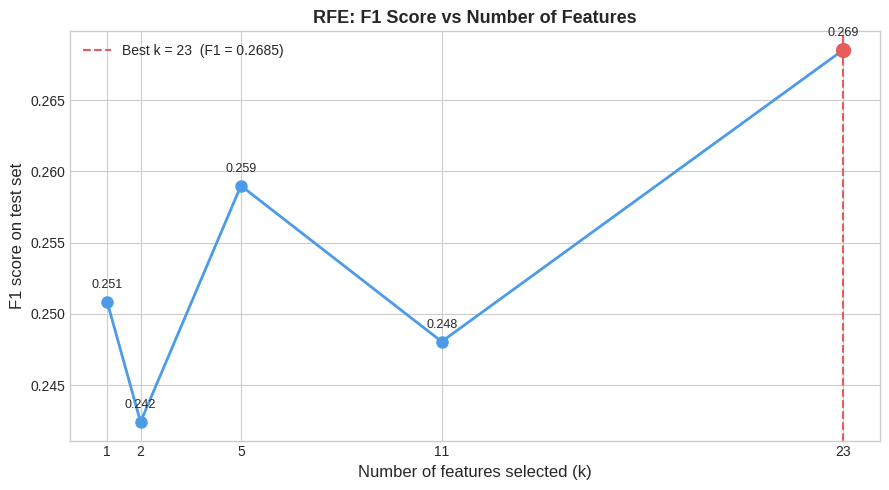

Best k = 23  (F1 = 0.2685)


In [17]:
# Find the index of the highest F1 score to determine the best 'k'
best_idx = int(np.argmax(f1_scores))
best_k   = feature_counts[best_idx]
best_f1  = f1_scores[best_idx]

# Set up the plot area
fig, ax = plt.subplots(figsize=(9, 5))

# Plot the F1 scores against the number of features
ax.plot(feature_counts, f1_scores, marker='o', linewidth=2, color='#4C9BE8', markersize=8)

# Add a vertical dashed line highlighting where the best 'k' is
ax.axvline(best_k, color='#E85C5C', linestyle='--', linewidth=1.5,
           label=f'Best k = {best_k}  (F1 = {best_f1:.4f})')

# Highlight the highest score point with a large red dot
ax.scatter([best_k], [best_f1], color='#E85C5C', zorder=5, s=100)

# Add text labels showing the exact F1 score near each point
for k, f1 in zip(feature_counts, f1_scores):
    ax.annotate(f'{f1:.3f}', (k, f1), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

# Add labels, title, and styling to make the plot look nice
ax.set_xlabel('Number of features selected (k)', fontsize=12)
ax.set_ylabel('F1 score on test set', fontsize=12)
ax.set_title('RFE: F1 Score vs Number of Features', fontsize=13, fontweight='bold')
ax.set_xticks(feature_counts)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Best k = {best_k}  (F1 = {best_f1:.4f})')

### Final RFE

Run the final RFE with the best `k` to produce the definitive selected feature list. Override `n_features_selected` if you prefer a different point from the plot.

In [18]:
n_features_selected = best_k   # <-- override here if needed

final_rfe = RFE(
    estimator=RandomForestClassifier(
        n_estimators=10, max_depth=4, class_weight='balanced', random_state=random_seed
    ),
    n_features_to_select=n_features_selected
)
final_rfe.fit(x_train_scaled, y_train)

selected_features = x_train_scaled.columns[final_rfe.support_].tolist()
print(f'Selected {len(selected_features)} features:')
for f in selected_features:
    print(f'  {f}')

Selected 23 features:
  Temp_max
  Temp_mean
  PaCO2_min
  BUN_max
  BUN_mean
  Creatinine_min
  Creatinine_max
  Lactate_min
  Lactate_max
  Lactate_mean
  Phosphate_min
  Phosphate_mean
  Potassium_mean
  Hct_max
  Hct_mean
  Hgb_max
  Hgb_mean
  PTT_mean
  WBC_min
  WBC_max
  Fibrinogen_max
  Platelets_min
  Platelets_max


In [19]:
x_train_final = x_train_scaled[selected_features]
x_test_final  = x_test_scaled[selected_features]

print(f'Final training set : {x_train_final.shape}')
print(f'Final test set     : {x_test_final.shape}')

Final training set : (3999, 23)
Final test set     : (1000, 23)


## 8. Save Output Files

In [20]:
x_train_final.to_csv(data_dir / 'X_train.csv')
x_test_final.to_csv(data_dir  / 'X_test.csv')
y_train.to_csv(data_dir       / 'y_train.csv')
y_test.to_csv(data_dir        / 'y_test.csv')

print(f'Saved to {data_dir}: X_train.csv, X_test.csv, y_train.csv, y_test.csv')

Saved to /content/drive/MyDrive/Colab Notebooks/Sepsis ML Project: X_train.csv, X_test.csv, y_train.csv, y_test.csv


## 9. Feature Reduction Summary

In [21]:
print('FEATURE REDUCTION SUMMARY')
print()
print(f'After aggregation         : {len(subset_df.columns) - 1}')
print(f'After zero-variance       : {len(subset_df.columns) - 1 - len(zero_var_cols)}')
print(f'After >90% null removal   : {len(subset_df.columns) - 1 - len(zero_var_cols) - len(high_null_cols)}')
print(f'After VarianceThreshold   : {n}')
print(f'After RFE (k={n_features_selected})            : {n_features_selected}')
print(f'Training : {x_train_final.shape[0]} patients x {x_train_final.shape[1]} features')
print(f'Test     : {x_test_final.shape[0]} patients x {x_test_final.shape[1]} features')
print()
print('Next: run 03_random_forest.ipynb')

FEATURE REDUCTION SUMMARY

After aggregation         : 104
After zero-variance       : 104
After >90% null removal   : 98
After VarianceThreshold   : 95
After RFE (k=23)            : 23
Training : 3999 patients x 23 features
Test     : 1000 patients x 23 features

Next: run 03_random_forest.ipynb
